In [1]:
import os
import pandas as pd
import shutil
import random

# Paths
csv_path = "osv-5m/train.csv"          # metadata
img_dir = "osv-5m/images/train_flat"   # flat image folder
subset_dir = "osv-5m_subset/train"     # where to save subset

# Create destination folder
os.makedirs(subset_dir, exist_ok=True)

# Load CSV
df = pd.read_csv(csv_path)
print("Total samples in CSV:", len(df))

# Randomly sample a subset (e.g., 10000)
subset_size = 10000
subset_df = df.sample(n=subset_size, random_state=42).reset_index(drop=True)
print("Subset size:", len(subset_df))

# Copy images for subset
copied = 0
for idx, row in subset_df.iterrows():
    img_id = str(row['id']).split('.')[0]   # in case 'id' includes '.jpg'
    filename = f"{img_id}.jpg"
    src = os.path.join(img_dir, filename)
    dst = os.path.join(subset_dir, filename)
    if os.path.exists(src):
        shutil.copy(src, dst)
        copied += 1

print(f"✅ Copied {copied} images to {subset_dir}")

# Save subset metadata
subset_csv_path = "osv-5m_subset/train_subset.csv"

/tmp/ipykernel_2049532/2795164680.py:15: DtypeWarning: Columns (11,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Total samples in CSV: 4894684
Subset size: 10000
✅ Copied 10000 images to osv-5m_subset/train


In [6]:
# Save the metadata to CSV
subset_df.to_csv(subset_csv_path, index=False)
print(f"💾 Saved metadata to {subset_csv_path}")

💾 Saved metadata to osv-5m_subset/train_subset.csv


In [4]:
# ===============================================================
# GeoGuessr Project: Data Analysis & Feature Work
# Author: Lifei Liu
# Goal: Explore, clean, and engineer features from OSV-5M dataset
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

# Display settings
pd.set_option('display.max_columns', 40)
sns.set(style="whitegrid")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [7]:
# ----------------------------
# 1. Load Dataset
# ----------------------------
data_path = "osv-5m_subset/train_subset.csv"  # Adjust as needed

# Suppress dtype warning and read CSV efficiently
df = pd.read_csv(data_path, low_memory=False)
print(f"✅ Dataset loaded. Shape: {df.shape}")
display(df.head())

✅ Dataset loaded. Shape: (10000, 32)


,id,latitude,longitude,thumb_original_url,country,sequence,captured_at,lon_bin,lat_bin,cell,region,sub-region,city,land_cover,road_index,drive_side,climate,soil,dist_sea,quadtree_10_5000,quadtree_10_25000,quadtree_10_1000,quadtree_10_50000,quadtree_10_12500,quadtree_10_500,quadtree_10_2500,unique_region,unique_sub-region,unique_city,unique_country,creator_username,creator_id
0,149569917138458,45.887541,22.451873,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,RO,9l9im94ivovbzy0qwgcpsl,1492440508000,55,74,"(55, 74)",Hunedoara,NaN,Lapugiu de Jos,3,2.698224,0,26,9,2.424399,2143,382,8789,205,839,13957,4152,Hunedoara_RO,NaN,Lapugiu de Jos_NaN_Hunedoara_RO,RO,pepenova,1.028911e+14
1,919724982215388,35.245933,140.005689,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,JP,eBS_n33kZpKWulqo48738g,1565936860035,88,66,"(88, 66)",Chiba,NaN,Kimitsu,4,6.107478,1,14,9,0.071070,1987,353,8038,190,774,12772,3823,Chiba_JP,NaN,Kimitsu_NaN_Chiba_JP,JP,drivephotograph,1.064098e+14
2,729329481758662,-36.143436,147.002683,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,AU,zeJO5Lj16QZCHb8dtrMNgD,1648998548000,90,13,"(90, 13)",New South Wales,Albury Municipality,East Albury,2,4.813778,1,14,0,0.748355,332,55,1183,34,121,1828,605,New South Wales_AU,Albury Municipality_New South Wales_AU,East Albury_Albury Municipality_New South Wale...,AU,skillsy,1.006477e+14
3,1929474523866300,38.465051,-28.288432,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,PT,VAjsepXiS_iq-Gy-d9QAdQ,1526313450615,41,69,"(41, 69)",Azores,Sao Roque do Pico,Sao Roque do Pico,4,6.016836,0,15,0,0.021335,1193,206,4742,111,456,7542,2305,Azores_PT,Sao Roque do Pico_Azores_PT,Sao Roque do Pico_Sao Roque do Pico_Azores_PT,PT,ligfietser,1.022241e+14
4,205345274735954,57.304645,25.211512,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,LV,ggxzc4t3d92422taut042v,1596196803683,56,83,"(56, 83)",Cesu Rajons,NaN,Cesis,4,3.049281,0,26,13,0.295797,2579,466,10682,243,987,17000,4955,Cesu Rajons_LV,NaN,Cesis_NaN_Cesu Rajons_LV,LV,karlis,1.100973e+14


In [8]:
# ----------------------------
# 2. Basic EDA
# ----------------------------
print("📊 Missing values:")
print(df.isnull().sum())

print("\n📋 Summary statistics:")
display(df.describe(include='all'))

# Top countries and regions
if 'country' in df.columns:
    print("\n🌍 Top 10 countries:")
    print(df['country'].value_counts().head(10))
else:
    print("⚠️ No 'country' column found in dataset.")

📊 Missing values:
id                       0
latitude                 0
longitude                0
thumb_original_url       0
country                  0
sequence                 0
captured_at              0
lon_bin                  0
lat_bin                  0
cell                     0
region                  55
sub-region            3315
city                     0
land_cover               0
road_index             201
drive_side               0
climate                  0
soil                     0
dist_sea                 0
quadtree_10_5000         0
quadtree_10_25000        0
quadtree_10_1000         0
quadtree_10_50000        0
quadtree_10_12500        0
quadtree_10_500          0
quadtree_10_2500         0
unique_region           55
unique_sub-region     3315
unique_city              0
unique_country           0
creator_username         0
creator_id               0
dtype: int64

📋 Summary statistics:


,id,latitude,longitude,thumb_original_url,country,sequence,captured_at,lon_bin,lat_bin,cell,region,sub-region,city,land_cover,road_index,drive_side,climate,soil,dist_sea,quadtree_10_5000,quadtree_10_25000,quadtree_10_1000,quadtree_10_50000,quadtree_10_12500,quadtree_10_500,quadtree_10_2500,unique_region,unique_sub-region,unique_city,unique_country,creator_username,creator_id
count,1.000000e+04,10000.000000,10000.000000,10000,10000,10000,1.000000e+04,10000.000000,10000.000000,10000,9945,6685,10000,10000.00000,9799.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.0000,9945,6685,10000,10000,10000,1.000000e+04
unique,NaN,NaN,NaN,10000,169,9910,NaN,NaN,NaN,996,1209,2654,7329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1228,2911,7600,169,2395,NaN
top,NaN,NaN,NaN,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,US,zfe0M3FCRCSoFoGqwM7jtu,NaN,NaN,NaN,"(68, 59)",California,Washington County,Grenfell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,California_US,Dallas County_Texas_US,Grenfell_Weddin_New South Wales_AU,US,lvl5,NaN
freq,NaN,NaN,NaN,1,2520,3,NaN,NaN,NaN,66,287,45,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,287,42,13,2520,682,NaN
mean,9.291635e+14,33.099074,-4.436177,NaN,NaN,NaN,1.540045e+12,47.504200,64.729900,NaN,NaN,NaN,NaN,2.86190,4.919829,0.166200,15.371700,8.63830,1.197978,1417.691400,248.738900,5693.317500,135.54750,545.493100,9044.778400,2724.2723,NaN,NaN,NaN,NaN,NaN,1.057805e+14
std,1.032161e+15,25.069442,74.774261,NaN,NaN,NaN,6.527864e+10,20.813051,18.591092,NaN,NaN,NaN,NaN,2.09458,1.058481,0.372279,8.545399,3.18818,1.503795,777.518953,143.304806,3283.130765,73.97389,301.823826,5223.500131,1505.9081,NaN,NaN,NaN,NaN,NaN,8.261521e+12
min,1.001202e+14,-46.450626,-158.207118,NaN,NaN,NaN,1.306748e+12,5.000000,6.000000,NaN,NaN,NaN,NaN,0.00000,2.057738,0.000000,0.000000,0.00000,0.000002,1.000000,1.000000,6.000000,1.00000,1.000000,7.000000,1.0000,NaN,NaN,NaN,NaN,NaN,1.001015e+14
25%,3.045118e+14,29.770453,-78.619132,NaN,NaN,NaN,1.496390e+12,27.000000,62.000000,NaN,NaN,NaN,NaN,1.00000,4.260851,0.000000,8.000000,9.00000,0.099189,778.000000,123.000000,2837.000000,72.00000,293.000000,4506.000000,1455.0000,NaN,NaN,NaN,NaN,NaN,1.028133e+14
50%,5.242223e+14,40.694510,7.275958,NaN,NaN,NaN,1.541076e+12,51.000000,70.000000,NaN,NaN,NaN,NaN,2.00000,5.481363,0.000000,14.000000,9.00000,0.556311,1415.000000,250.000000,5693.000000,136.00000,544.000000,9054.000000,2733.0000,NaN,NaN,NaN,NaN,NaN,1.049723e+14
75%,9.983208e+14,48.822954,28.482178,NaN,NaN,NaN,1.584801e+12,57.000000,76.000000,NaN,NaN,NaN,NaN,4.00000,5.733500,0.000000,26.000000,10.00000,1.757560,2098.000000,374.000000,8570.250000,201.00000,821.000000,13610.500000,4058.2500,NaN,NaN,NaN,NaN,NaN,1.089910e+14



🌍 Top 10 countries:
country
US    2520
DE     535
FR     476
RU     471
JP     446
AU     317
BR     280
SE     280
GB     264
IT     237
Name: count, dtype: int64


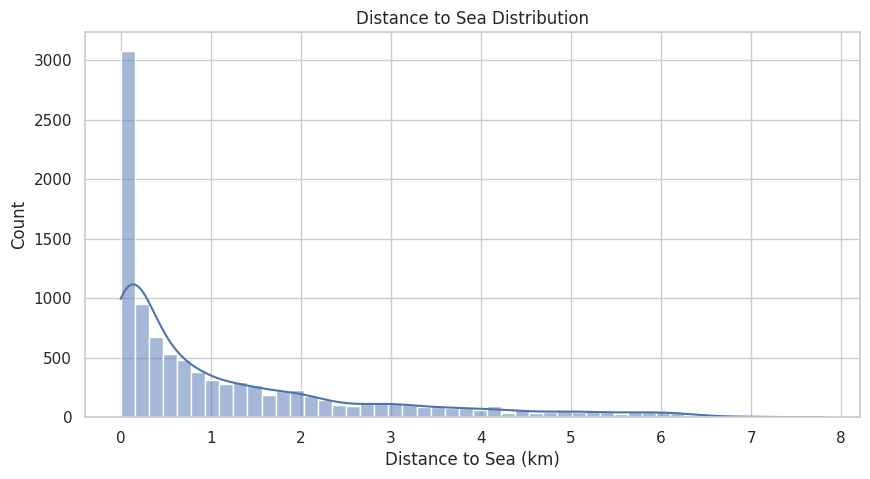

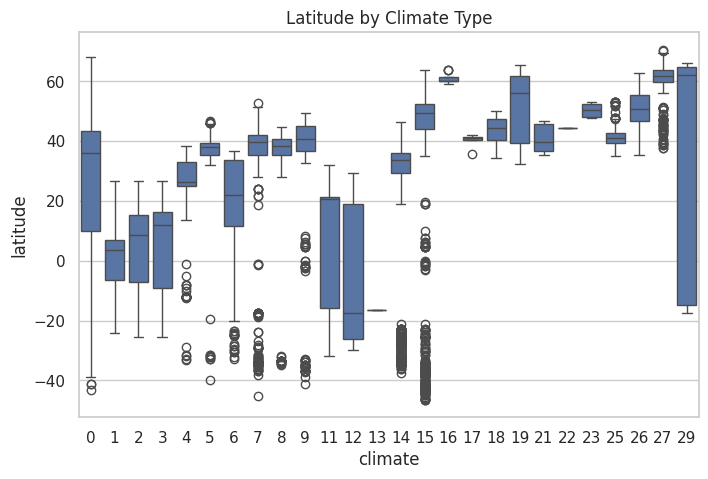

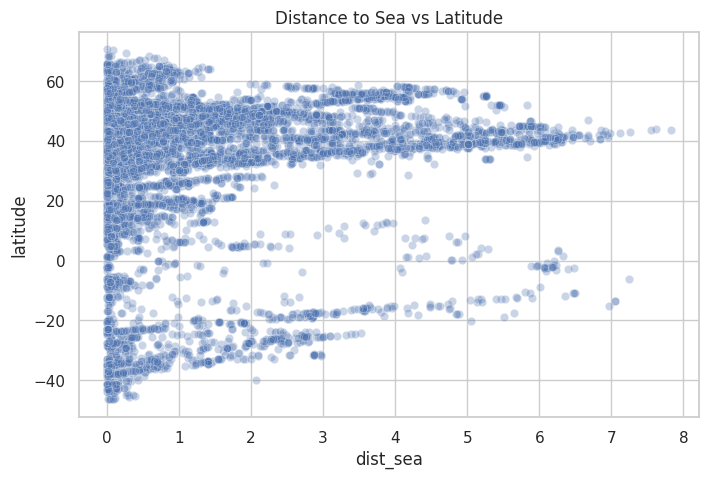

In [9]:
# ----------------------------
# 3. Visualize Feature Distributions
# ----------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['dist_sea'], bins=50, kde=True)
plt.title("Distance to Sea Distribution")
plt.xlabel("Distance to Sea (km)")
plt.ylabel("Count")
plt.show()

if 'climate' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='climate', y='latitude', data=df)
    plt.title("Latitude by Climate Type")
    plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='dist_sea', y='latitude', data=df, alpha=0.3)
plt.title("Distance to Sea vs Latitude")
plt.show()

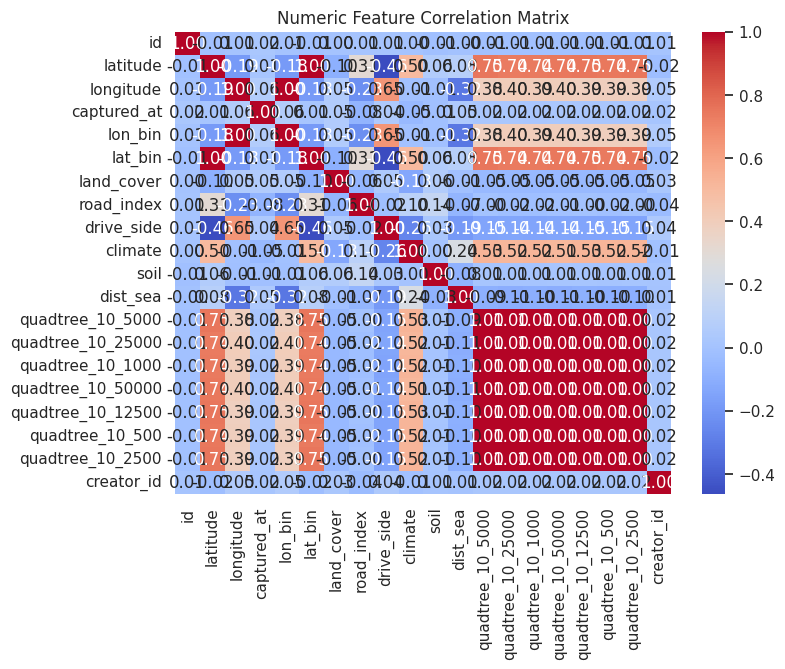


📈 Correlation with Latitude:
 latitude             1.000000
lat_bin              0.999879
quadtree_10_2500     0.753826
quadtree_10_5000     0.753588
quadtree_10_12500    0.750612
quadtree_10_50000    0.743966
quadtree_10_500      0.742993
quadtree_10_1000     0.741303
quadtree_10_25000    0.736830
climate              0.498023
Name: latitude, dtype: float64

📈 Correlation with Longitude:
 longitude            1.000000
lon_bin              0.999900
drive_side           0.647676
quadtree_10_25000    0.402921
quadtree_10_50000    0.399409
quadtree_10_1000     0.394733
quadtree_10_500      0.392911
quadtree_10_12500    0.386973
quadtree_10_2500     0.386148
quadtree_10_5000     0.384105
Name: longitude, dtype: float64


In [10]:
# ----------------------------
# 4. Correlation Analysis
# ----------------------------
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Numeric Feature Correlation Matrix")
plt.show()

# Identify which features correlate most with lat/lon
if 'latitude' in corr.columns:
    lat_corr = corr['latitude'].sort_values(ascending=False)
    print("\n📈 Correlation with Latitude:\n", lat_corr.head(10))

if 'longitude' in corr.columns:
    lon_corr = corr['longitude'].sort_values(ascending=False)
    print("\n📈 Correlation with Longitude:\n", lon_corr.head(10))

In [11]:
# ----------------------------
# 5. Feature Engineering
# ----------------------------
if 'dist_sea' in df.columns:
    df['is_coastal'] = (df['dist_sea'] < 10).astype(int)

if {'latitude', 'longitude'}.issubset(df.columns):
    df['lat_norm'] = df['latitude'] / 90.0
    df['lon_norm'] = df['longitude'] / 180.0

categorical_features = [col for col in ['land_cover', 'climate', 'soil'] if col in df.columns]
df = pd.get_dummies(df, columns=categorical_features)

print("✅ Added engineered features.")
print("New shape:", df.shape)

✅ Added engineered features.
New shape: (10000, 83)


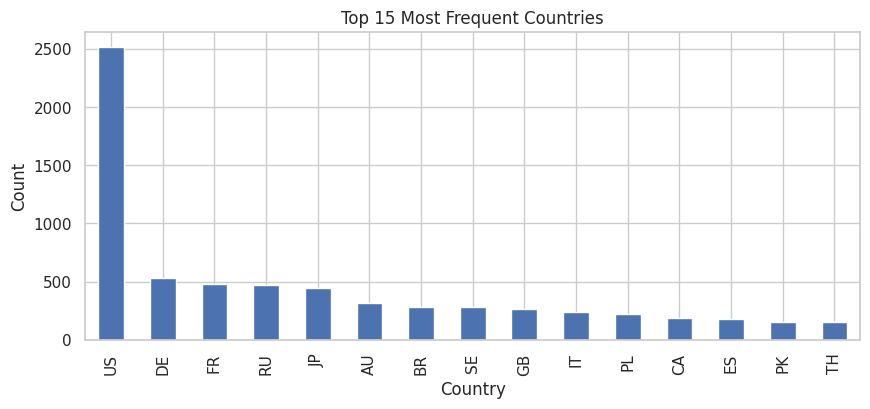

✅ Balanced dataset shape: (9480, 83)


/tmp/ipykernel_2049532/2440961321.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 2000), random_state=42))


In [12]:
# ----------------------------
# 6. Check Regional Balance
# ----------------------------
if 'country' in df.columns:
    plt.figure(figsize=(10,4))
    df['country'].value_counts().head(15).plot(kind='bar')
    plt.title("Top 15 Most Frequent Countries")
    plt.xlabel("Country")
    plt.ylabel("Count")
    plt.show()

    # Downsample to reduce geographic bias
    balanced_df = (
        df.groupby('country', group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 2000), random_state=42))
        .reset_index(drop=True)
    )
else:
    print("⚠️ 'country' column not found, skipping balancing.")
    balanced_df = df.copy()

print("✅ Balanced dataset shape:", balanced_df.shape)

In [13]:
# ----------------------------
# 7. Save Processed Data
# ----------------------------
output_file = "osv_processed_features.csv"
balanced_df.to_csv(output_file, index=False)
print(f"💾 Processed dataset saved to {output_file}")

💾 Processed dataset saved to osv_processed_features.csv


In [14]:
# ===============================================================
# 📘 Summary: Data Processing Pipeline for GeoGuessr Project
# ===============================================================
# This notebook loads a subset of the OSV-5M dataset (train_subset.csv),
# performs exploratory data analysis (EDA), feature engineering,
# and optional geographic balancing.
#
# ✅ Key steps performed:
#   1. Load the subset metadata and inspect missing values & distributions.
#   2. Visualize correlations between features and target coordinates.
#   3. Engineer new features:
#        - is_coastal  →  binary flag for near-sea locations
#        - lat_norm, lon_norm  →  normalized coordinates for modeling
#   4. One-hot encode categorical variables (land_cover, climate, soil).
#   5. Optionally balance data across countries (≤2000 samples each).
#   6. Save the cleaned, encoded dataset as 'osv_processed_features.csv'.
#
# 💾 Output:
#   - 'osv_processed_features.csv' is the **final preprocessed dataset**
#     ready for machine learning models.
#   - It can be used for:
#       • Training regression models (e.g., Random Forest, XGBoost)
#         to predict latitude & longitude.
#       • Serving as metadata input for the ResNet image-based model.
#
# 🧩 How to use next:
#   - Load this CSV in a new notebook:
#         df = pd.read_csv("osv_processed_features.csv")
#   - Split into features (X) and targets (y = ['latitude', 'longitude'])
#   - Train and evaluate your model (e.g., compute RMSE or Haversine distance).
#
# Example usage:
#   from sklearn.ensemble import RandomForestRegressor
#   X = df.drop(['latitude', 'longitude'], axis=1)
#   y = df[['latitude', 'longitude']]
#   model = RandomForestRegressor().fit(X, y)
#
# ===============================================================
# End of Data Analysis & Feature Work notebook
# ===============================================================